### Notebook creado para testear las mejoras o correciones sobre CROP. solo a nivel funcional.

2025-11-18 20:55:43.654644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-18 20:55:43.658695: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-18 20:55:43.670458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763510143.687628   19086 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763510143.692465   19086 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763510143.721629   19086 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


E0000 00:00:1763510148.216418   19086 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763510148.216994   19086 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


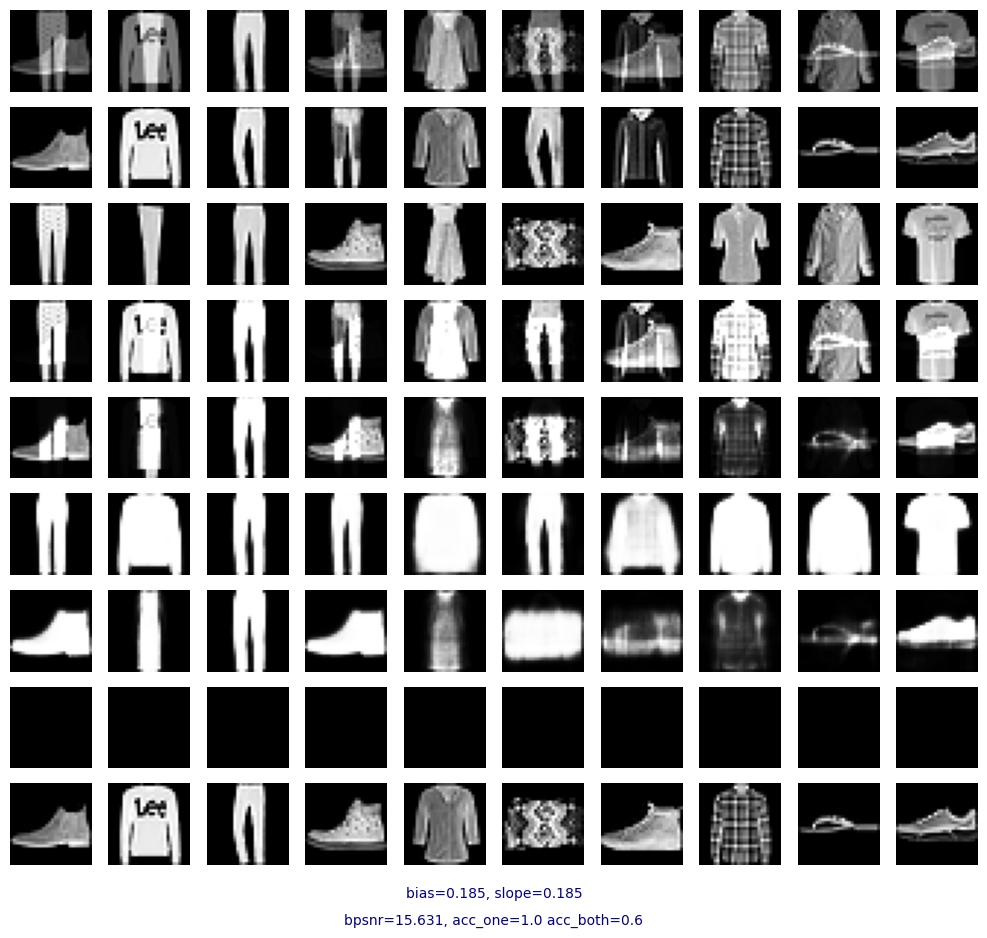

(<tf.Tensor: shape=(), dtype=float32, numpy=15.631418228149414>, <tf.Tensor: shape=(), dtype=float32, numpy=2.4072885513305664>)
1.0
0.6


In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from project.trained_models import load
from project.CROP.models.crop1_model import Crop1 # se tendria que poder cargar todo desde aca. 

dataset = "fashion"

data = load.data(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]

predictor = load.predictor(dataset=dataset)
model = load.cvae(lat=64, inter=128, dataset=dataset) 

crop_f0 = Crop1(
    cvae=model,              #se arma con el CVAE, predictor.
    predictor=predictor,
    bias=0.18495822150909808, #pasar como parametro del método
    slope=18.248678323921897, # pasar como parte del metodo
    beta=1,                   # pasar como parametro del metodo. 
)

start = 0
end = start + 10


metrics = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True,
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])